### Library import

In [1]:
import numpy as np  # math library
import pandas as pd  # Library to handle databases
import matplotlib.pyplot as plt  # Graphic library
from scipy import stats  # stat library
import seaborn as sns  # Graphic library specialized in stats
import statsmodels.api as sm  # statistic modelling library

# Notions of Bias and Variance

Suppose that $X_1,\dots,X_N$ are i.i.d from an exponential distribution of parameter $\mu=\mathbb{E}[X]=3$ with $N=51$, we can estimate the mean $\mu$ using the empirical mean
$$\widehat\mu_1=\frac{1}{n}\sum_{i=1}^n X_i =\overline{X}.$$
 $\widehat \mu_1$ is also the estimator obtained by the method of moments.
Now, we could consider another estimator given by
$$\widehat \mu_2 = \frac{1}{\log(2)}\mathrm{median}(X_1,\dots,X_N)$$
where $\mathrm{median}(X_1,\dots,X_N)=X_{i_{med}}$ such that the number of $X_i$'s strictly smaller than $X_{i_{med}}$ is equal to the number of $X_i$'s strictly greater than $X_{i_{med}}$ which is equal to $\lceil  N/2\rceil$ (recall that $N$ is odd, if $N=2p+1$, $\lceil  N/2\rceil=p+1$). We can show that the theoretical median of an exponential of parameter $\mu$ is given by $\mu\log(2)=\mathbb{E}[X]\log(2)$.
Then, the question is how to assess the respective performances of $\widehat \mu_1$ and $\widehat \mu_2$, we will do a simulation study to see which estimator is better.

### Question 1 :
It can be shown that
$$\mathbb{E}[\mathrm{median}(X_1,\dots,X_N)]=\mu\sum_{i=1}^{\lceil N/2\rceil}\frac{1}{N-i+1}\quad \text{and}\quad \mathrm{Var}(\mathrm{median}(X_1,\dots,X_N))=\mu^2\sum_{i=1}^{\lceil N/2\rceil}\frac{1}{(N-i+1)^2}$$

Compute the value of the bias, the variance and the risk (with respect to the squared loss) of the estimators $\widehat \mu_1$ and $\widehat \mu_2$.

Hint: what is the variance of the sum of i.i.d random variables ?

Answer here...
N(Var(X))

In [3]:
mu = 3
N = 51

# Empirical mean estimator (method of moments)
bias_mu1 = 0  # unbiased
variance_mu1 = mu**2 / N  # variance of mean of exponential

# Median-based estimator
# Theoretical median of exponential: mu * log(2)
# E[median] = mu * sum_{i=1}^{ceil(N/2)} 1/(N-i+1)
# Var(median) = mu**2 * sum_{i=1}^{ceil(N/2)} 1/(N-i+1)**2
from math import ceil, log

median_sum = sum([1/(N-i+1) for i in range(1, ceil(N/2)+1)])
median_var_sum = sum([1/(N-i+1)**2 for i in range(1, ceil(N/2)+1)])

bias_mu2 = mu * median_sum / log(2) - mu  # bias of median estimator
variance_mu2 = (mu**2 * median_var_sum) / (log(2)**2)  # variance of median estimator


bias_mu1, variance_mu1, bias_mu2, variance_mu2

(0, 0.17647058823529413, 0.04201628496296639, 0.37078376600118995)

### Question 2:
In this question we illustrate Question 1.
We do 100 experiments, in each experiment we begin by sampling according to an exponential of parameter $\mu = 3$, then we compute the distance between the estimator and the true mean (that we know because it is a simulation study) and then we plot the boxplots of these distances. The boxplots allow us to visualize the distributions of the two estimators.

C:\Users\Sukhjot Kaur\AppData\Local\Temp\ipykernel_36044\803335535.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([distance_mu1, distance_mu2], labels=[r'$\widehat \mu_1$', r'$\widehat \mu_2$'])


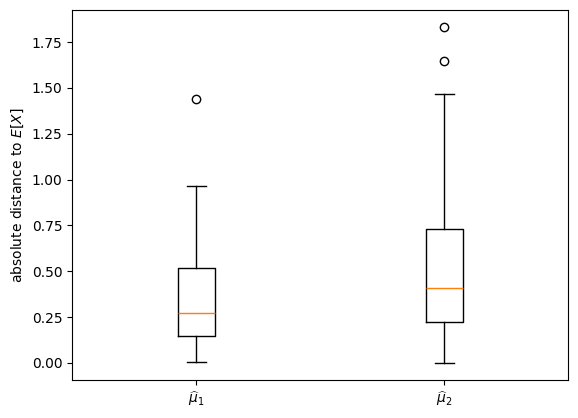

In [4]:
M = 100  # Number of different experiments
N = 51  # sample size
mu = 3  # parameter of the exponential distribution
th_mean = mu  # theoretical mean of the exponential distribution

distance_mu1 = []
distance_mu2 = []
for i in range(M):
    rng = np.random.RandomState(i)  # we fix the seed of the random number generator
    X = rng.exponential(scale=mu, size=N)  # sample of the exponential distribution
    mu1 = np.mean(X)
    mu2 = np.median(X) / np.log(2)
    distance_mu1.append(abs(mu1 - th_mean))
    distance_mu2.append(abs(mu2 - th_mean))

plt.boxplot([distance_mu1, distance_mu2], labels=[r'$\widehat \mu_1$', r'$\widehat \mu_2$'])
plt.ylabel('absolute distance to $E[X]$')
plt.show()

Which estimator seems to be most efficient ?

Answer here...
distances are smaller for hmu1, so it seems more efficient than hmu2

# Histogram and density estimation
Another type of estimation is density estimation in which we try to approximate the density of some random variable for which we have only access to a sample. One such estimator is the histogram.

### Question 3
Simulate $N=100$ samples from a uniform distribution on $(0,1)$ and plot its histogram. Add in the same plot the theoretical density.

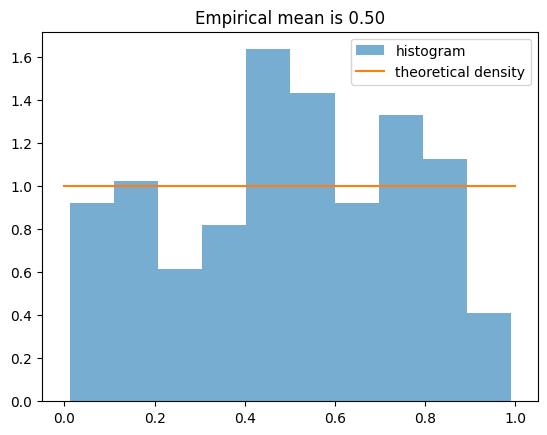

In [5]:
N = 100
U = np.random.uniform(0,1,size=N)  # sample of uniform distribution (Use the function numpy.random.uniform)
plt.hist(U, density=True, label='histogram',
         alpha=0.6)  # the "density=True" indicate that we want the histogram to be renormalized so that the area under the curve is 1
plt.plot(np.linspace(0, 1, num=100), np.ones(100), label='theoretical density')
plt.legend()

empirical_mean = np.mean(U)
plt.title(f'Empirical mean is {empirical_mean:.2f}')
plt.show()

### Question 4
Plot the empirical CDF and the theoretical CDF of the uniform distribution previously sampled.

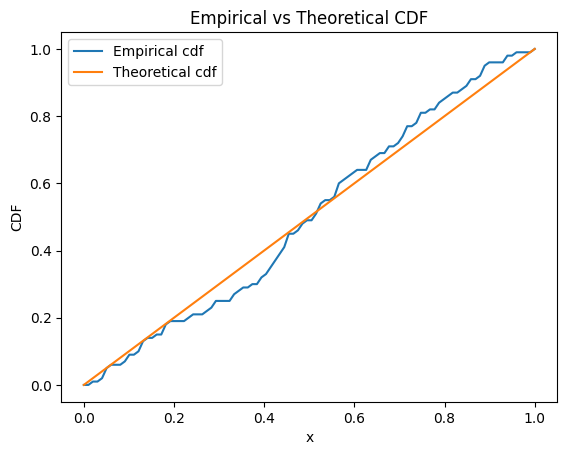

In [8]:
xplot = np.linspace(0, 1, num=100)


def empirical_cdf(x):
    return np.mean(U<=x)  # function to compute the empirical cdf


y_ecdf = [empirical_cdf(x) for x in xplot]  # values of the empirical cdf on xplot
y_cdf = xplot  # values of the theoretical cdf on xplot (look into the stats module from scipy)
plt.plot(xplot, y_ecdf, label='Empirical cdf')
plt.plot(xplot, y_cdf, label='Theoretical cdf')
plt.xlabel('x')
plt.ylabel('CDF')
plt.title('Empirical vs Theoretical CDF')
plt.legend()
plt.show()

# Model validation or how well does my model fit the data ?

### Question 5
In the lectures, we define the empirical quantile of level $\alpha$, $\widehat{q}_{N,\alpha}$, for a sample $(x_1,\dots,x_N)$ from a law $F$ as the quantile of the empirical CDF.
These empirical quantiles are estimators of the theoretical quantiles.

A way to assess the fit of a model is to use a so-called QQ-plot, the quantile-quantile plot. The principle of the QQ-plot is to compare the empirical quantiles to the theoretical quantiles of the law. The QQ-plot is the plot of the points
$$\left(\widehat{q}_{N,i},F^{-1}\left(\frac{i}{N+1}\right)\right) \quad \text{for $1\le i\le N$} $$

Generate a sample of size $N=30$ from a Gaussian distribution $\mathcal{N}(0,1)$ and plot the QQ-plot associated to this sample and to the Gaussian distribution. Add the line $y=x$ for comparison purposes.

In [9]:
?sm.qqplot

Signature:
sm.qqplot(
    data,
    dist=<scipy.stats._continuous_distns.norm_gen object at 0x0000022B2C5BB8F0>,
    distargs=(),
    a=0,
    loc=0,
    scale=1,
    fit=False,
    line=None,
    ax=None,
    **plotkwargs,
)
Docstring:
Q-Q plot of the quantiles of x versus the quantiles/ppf of a distribution.

Can take arguments specifying the parameters for dist or fit them
automatically. (See fit under Parameters.)

Parameters
----------
data : array_like
    A 1d data array.
dist : callable
    Comparison distribution. The default is
    scipy.stats.distributions.norm (a standard normal).
distargs : tuple
    A tuple of arguments passed to dist to specify it fully
    so dist.ppf may be called.
a : float
    Offset for the plotting position of an expected order statistic, for
    example. The plotting positions are given by (i - a)/(nobs - 2*a + 1)
    for i in range(0,nobs+1)
loc : float
    Location parameter for dist
scale : float
    Scale parameter for dist
fit : bool
    If f

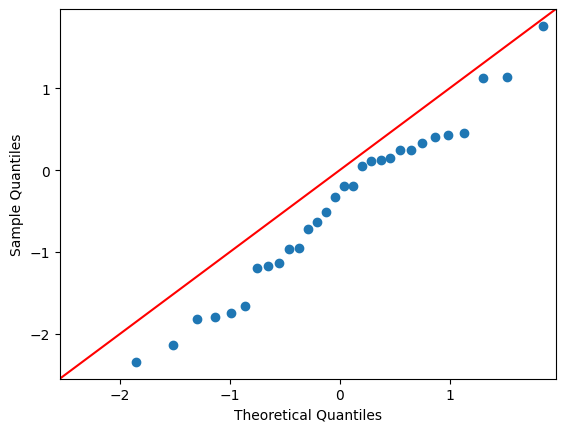

In [12]:
U = np.random.normal(loc=0, scale=1, size=30)  # sample of normal distribution (Look into the random module from numpy)
sm.qqplot(U, stats.norm, line='45')  # check the doc of 'sm.qqplot' to find what to put in here
plt.show()

### Question 6
We import a real dataset.

We use the quine dataset whose doc is the following. The quine data frame has 146 rows and 5 columns. Children from Walgett, New South Wales, Australia, were classified by Culture, Age, Sex and Learner status and the number of days absent from school in a particular school year was recorded.

In [13]:
# Import of the real dataset
df = sm.datasets.get_rdataset("quine", "MASS").data

In [14]:
df

,Eth,Sex,Age,Lrn,Days
0,A,M,F0,SL,2
1,A,M,F0,SL,11
2,A,M,F0,SL,14
3,A,M,F0,AL,5
4,A,M,F0,AL,5
...,...,...,...,...,...
141,N,F,F3,AL,5
142,N,F,F3,AL,15
143,N,F,F3,AL,18
144,N,F,F3,AL,22


Here is an histogram of the variable "Days", which law do you propose to model these data ?

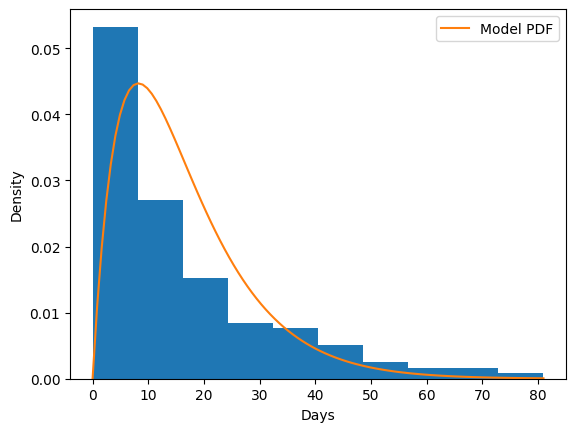

In [38]:
# plot histogram
plt.hist(df['Days'], density=True)

# define the distribution
model = stats.norm(loc=0, scale=25)  # this must be a scipy.stats law object
# todo: try different distributions and different sets of parameters to get some intuition. The rest of this notebook, if done properly, will not throw errors when using the Gaussian distribution. However, some adaptation might be needed for different distribution, i.e. for discrete distribution for example.
model=stats.norm(loc=np.mean(df['Days']), scale=np.std(df['Days']))
model=stats.poisson(mu=np.mean(df['Days']))
model=stats.expon(loc=0, scale=np.mean(df['Days']))
model=stats.gamma(a=2, scale=np.mean(df['Days'])/2)
# plot the density
x = np.linspace(min(df['Days']), max(df['Days']), 100)  # find out the ranges of the data
plt.plot(x, model.pdf(x), label='Model PDF')

# add labels and legend
plt.xlabel('Days')
plt.ylabel('Density')
plt.legend()
plt.show()

## Question 7

We fit a model to the dataset.

Estimate the parameter of the law considered. Then, add the theoretical density to the histogram. Do you think the model is a good fit for the dataset ?

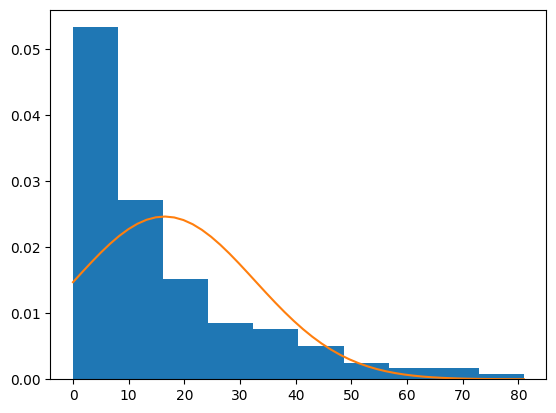

In [39]:
model = stats.norm

# =============================================================================
# determine the parameters as the following example
mu = np.mean(df['Days'])
var = np.var(df['Days'])
# fix the parameters in the model
law = model(loc=mu, scale=np.sqrt(var))
# =============================================================================

# plot the histogram and the theoretical density
xplot = np.linspace(min(df['Days']), max(df['Days']))  # find out the ranges of the data
plt.hist(df['Days'], density=True)
plt.plot(xplot, law.pdf(xplot))
plt.show()

### Question 8
Interpreting an histogram directly can be misleading, a better way to assess a goodness of fit is to draw a QQ-plot.

Plot the QQ-plot of the dataset against the estimated theoretical law. Use the estimated parameter to compute the theoretical quantiles of the law.

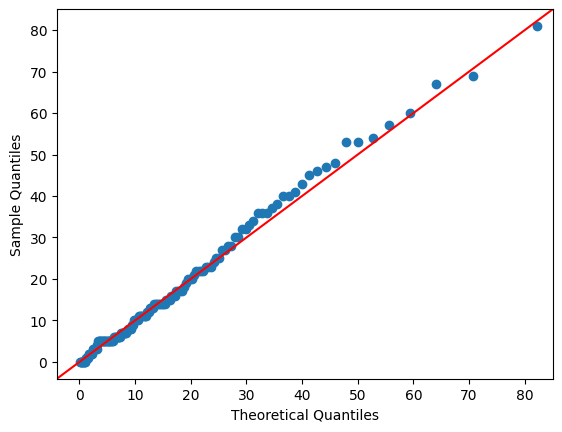

In [46]:
sm.qqplot(df['Days'],
          stats.expon(scale=np.mean(df['Days'])), # must be a scipy.stats law object
          line='45')  # the line="45" automatically plot the 45° line, which is useful to compare the two distributions
plt.show()

Is the proposed model adequate ?
Why is the 45° line useful to assess the goodness of fit ?

Answer here...<br>
Is the proposed model adequate?<br>
The exponential distribution closely matches the histogram of the data, it is a reasonable model for the variable "Days".<br>
<br>
Why is the 45° line useful to assess the goodness of fit?<br>
The 45° line in a QQ-plot represents perfect agreement between the empirical quantiles and the theoretical quantiles of the chosen model. If the points in the QQ-plot closely follow this line, it indicates that the data fits the model well. Deviations from the line suggest discrepancies between the data and the model.